In [25]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [12]:
from google.colab import files

uploaded = files.upload()

Saving News_Classification_Labeling.xlsx to News_Classification_Labeling.xlsx


In [13]:
df = pd.read_excel("News_Classification_Labeling.xlsx")

print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset Shape: (5000, 3)
Columns: ['URL', 'Title', 'Category']


In [14]:
# Remove rows where Category is missing
df = df.dropna(subset=["Category"]).copy()

# Keep only the columns we need
df = df[["Title", "Category"]].copy()

# Make sure text and labels are strings
df["Title"] = df["Title"].astype(str)
df["Category"] = df["Category"].astype(str)

# Encode categories into numbers
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["Category"])

# Number of classes
num_labels = len(label_encoder.classes_)

print("Number of rows:", len(df))
print("Number of classes:", num_labels)
print("\nClasses:")

for i, name in enumerate(label_encoder.classes_):
    print(i, "->", name)

print("\nClass distribution:")
print(df["Category"].value_counts())

Number of rows: 4999
Number of classes: 6

Classes:
0 -> Business
1 -> Energy
2 -> Health
3 -> Markets
4 -> Politics
5 -> Technology

Class distribution:
Category
Business      1896
Markets       1518
Politics       862
Technology     452
Health         144
Energy         127
Name: count, dtype: int64


In [15]:
# 80% training, 10% validation, 10% testing

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 3999
Validation: 500
Test: 500


In [16]:
train_dataset = Dataset.from_pandas(
    train_df[["Title", "label"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[["Title", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["Title", "label"]],
    preserve_index=False
)

print("Train dataset:", train_dataset)
print("Validation dataset:", val_dataset)
print("Test dataset:", test_dataset)

Train dataset: Dataset({
    features: ['Title', 'label'],
    num_rows: 3999
})
Validation dataset: Dataset({
    features: ['Title', 'label'],
    num_rows: 500
})
Test dataset: Dataset({
    features: ['Title', 'label'],
    num_rows: 500
})


In [17]:
MODEL_NAME = "roberta-base"

roberta_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("RoBERTa tokenizer loaded successfully.")

RoBERTa tokenizer loaded successfully.


In [18]:
def tokenize_function(examples):
    return roberta_tokenizer(
        examples["Title"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Tokenization completed.")

Map:   0%|          | 0/3999 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenization completed.


In [19]:
train_tokenized = train_tokenized.remove_columns(["Title"])
val_tokenized = val_tokenized.remove_columns(["Title"])
test_tokenized = test_tokenized.remove_columns(["Title"])

train_tokenized.set_format("torch")
val_tokenized.set_format("torch")
test_tokenized.set_format("torch")

print("Training examples:", len(train_tokenized))
print("Validation examples:", len(val_tokenized))
print("Test examples:", len(test_tokenized))

Training examples: 3999
Validation examples: 500
Test examples: 500


In [20]:
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)

print("RoBERTa classification model ready.")
print("Number of classes:", num_labels)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa classification model ready.
Number of classes: 6


In [21]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Metrics function ready.")

Metrics function ready.


In [22]:
training_args = TrainingArguments(
    output_dir="./roberta_news_results",

    num_train_epochs=5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    learning_rate=2e-5,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_steps=50,
    report_to="none"
)

print("Training configuration ready.")
print("Epochs: 5")
print("Batch size: 16")
print("Learning rate: 2e-5")

Training configuration ready.
Epochs: 5
Batch size: 16
Learning rate: 2e-5


In [23]:
roberta_trainer = Trainer(
    model=roberta_model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=roberta_tokenizer,
    compute_metrics=compute_metrics
)

print("RoBERTa Trainer ready.")

RoBERTa Trainer ready.


In [24]:
roberta_train_result = roberta_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.830243,0.760906,0.692000,0.679741,0.692000,0.683564
2,0.665808,0.768442,0.710000,0.718062,0.710000,0.710461
3,0.478162,0.803689,0.716000,0.717100,0.716000,0.714793


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.830243,0.760906,0.692000,0.679741,0.692000,0.683564
2,0.665808,0.768442,0.710000,0.718062,0.710000,0.710461
3,0.478162,0.803689,0.716000,0.717100,0.716000,0.714793
4,0.425202,0.825992,0.708000,0.713294,0.708000,0.708292
5,0.349393,0.876879,0.716000,0.719139,0.716000,0.715714


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [26]:
roberta_test_results = roberta_trainer.evaluate(test_tokenized)

print("RoBERTa Test Results:")
print(f"Accuracy : {roberta_test_results['eval_accuracy']:.4f}")
print(f"Precision: {roberta_test_results['eval_precision']:.4f}")
print(f"Recall   : {roberta_test_results['eval_recall']:.4f}")
print(f"F1 Score : {roberta_test_results['eval_f1']:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.349393,0.898736,5,0.714000,0.714199,0.714000,0.712808


RoBERTa Test Results:
Accuracy : 0.7140
Precision: 0.7142
Recall   : 0.7140
F1 Score : 0.7128


In [27]:
# Get predictions on the test set
predictions = roberta_trainer.predict(test_tokenized)

# Convert logits to predicted class numbers
y_pred = np.argmax(predictions.predictions, axis=1)

# Actual labels
y_true = predictions.label_ids

# Classification Report
print("RoBERTa Classification Report")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_,
        digits=2
    )
)

RoBERTa Classification Report
              precision    recall  f1-score   support

    Business       0.69      0.68      0.68       190
      Energy       0.58      0.58      0.58        12
      Health       0.70      0.47      0.56        15
     Markets       0.73      0.72      0.73       152
    Politics       0.77      0.78      0.77        86
  Technology       0.69      0.82      0.75        45

    accuracy                           0.71       500
   macro avg       0.69      0.68      0.68       500
weighted avg       0.71      0.71      0.71       500



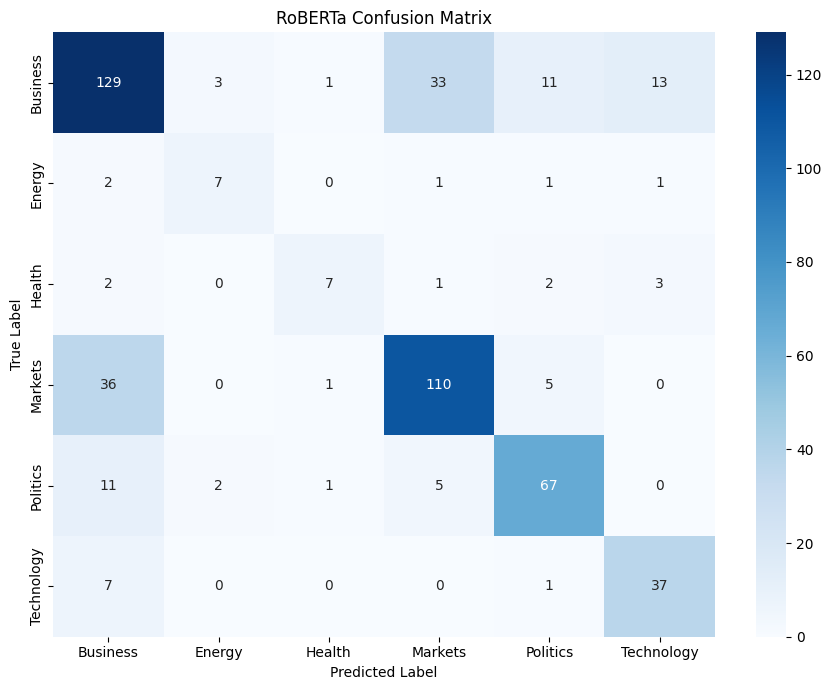

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("RoBERTa Confusion Matrix")

plt.tight_layout()
plt.show()

In [29]:
results = pd.DataFrame({
    "Model": ["DistilBERT", "RoBERTa"],
    "Test Accuracy": [0.7020, 0.7140],
    "Test Precision": [0.7015, 0.7142],
    "Test Recall": [0.7020, 0.7140],
    "Test F1": [0.7003, 0.7128]
})

results

,Model,Test Accuracy,Test Precision,Test Recall,Test F1
0,DistilBERT,0.702,0.7015,0.702,0.7003
1,RoBERTa,0.714,0.7142,0.714,0.7128


In [30]:
accuracy_improvement = (0.7140 - 0.7020) * 100
f1_improvement = (0.7128 - 0.7003) * 100

print(f"Accuracy improvement: +{accuracy_improvement:.2f} percentage points")
print(f"F1 improvement: +{f1_improvement:.2f} percentage points")

Accuracy improvement: +1.20 percentage points
F1 improvement: +1.25 percentage points


In [31]:
results.to_csv(
    "transformer_model_comparison.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.
